In [12]:
import util
from models import EEGNet, EEGNet_TF, EEGNet_Wavelet, ShallowConvNet, DeepConvNet

from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from matplotlib import pyplot as plt
from tensorflow.keras import utils as np_utils
from pyriemann.utils.viz import plot_confusion_matrix

In [13]:
input_format = "timeseries"
model_type = "EEGNet"

#training_files = ["A01T", "A02T", "A03T","A04T", "A05T", "A06T", "A07T", "A08T", "A09T"]
#test_files = ["A01E", "A02E", "A03E", "A04E", "A05E", "A06E", "A07E", "A08E", "A09E"]

# STATIC
#training_files = ["B0101T", "B0102T", "B0103T"]
#test_files = ["B0104E", "B0105E"]
training_files = ["A01T"]
test_files = ["A01E"]
tmin, tmax = 0.5, 2.5 # seconds before and after stimulus we want to record  # From the paper describing dataset
#tmin, tmax = 0, 3.996
classes = 4

#PREPROCESSING
bandpass = [4,40]
baseline = None
amplitude_magnification = 1000 #current best = 1000

#STFT
segment_len=128
sample_overlap=64
boundary=None
padding=True

#WAVELET
n_freqs = 30

#MODEL HYPERPARAMS
dropoutRate = 0.5
kernLength = 32
F1 = 8
D = 2
F2 = 16
dropoutType = 'Dropout'
stop_threshold = 0

# INVESTIGATE CHANGING BOUNDARY AND PADDING -> Try to get less than 17 windows -> Maybe 14
# add these as params also

In [14]:
X_train, Y_train, X_test, Y_test, chans, kernels, samples, names, sample_rate = util.get_bci_2a(
    training_files, test_files, 
    bandpass = bandpass,
    tmin = tmin, tmax = tmax,
    mode = "gdf",
    amp_mag= amplitude_magnification, 
    baseline=baseline
    )
if input_format == "stft":
    X_train, X_test, freq_bins_centers, time_window_centers = util.convert_stft(X_train, X_test, sample_rate, segment_len, sample_overlap, boundary, padding)
if input_format=="wavelet":
    X_train, X_test = util.convert_wavelet(X_train, X_test,sample_rate, n_freqs)

/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:374: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.
/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:374: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the

In [15]:
# take 50/25/25 percent of the data to train/validate/test
X_train, X_validate, Y_train, Y_validate = train_test_split(X_train, Y_train, test_size=0.2, stratify=Y_train)
if input_format == "timeseries":
    print(X_train.shape)
    X_train      = X_train.reshape(X_train.shape[0], chans, samples, kernels)
    X_validate   = X_validate.reshape(X_validate.shape[0], chans, samples, kernels)
    X_test       = X_test.reshape(X_test.shape[0], chans, samples, kernels)


Y_train = np_utils.to_categorical(Y_train) # One hot encoding format for probabilistic classification
Y_validate = np_utils.to_categorical(Y_validate) # One hot encoding format for probabilistic classification
Y_test = np_utils.to_categorical(Y_test) # One hot encoding format for probabilistic classification

# 2) Standardize per-channel (over time & trials)
#mean  = X_train.mean(axis = (0,2), keepdims=True)
#std   = X_train.std(axis = (0,2), keepdims=True)
#X_train    = (X_train   - mean) / std
#X_validate = (X_validate- mean) / std
#X_test     = (X_test    - mean) / std

(230, 22, 500)


In [16]:
# The ChatGPT generated wavelet model likes this format input

if input_format=="wavelet":
    X_train = np.transpose(X_train, (0, 2, 3, 1))
    X_validate = np.transpose(X_validate, (0, 2, 3, 1)) 
    X_test = np.transpose(X_test, (0, 2, 3, 1))

In [17]:
"""if input_format=="wavelet":
    chans = 3
    X_train = X_train[:,:,:,[7,9,11]]
    X_validate = X_validate[:,:,:,[7,9,11]]
    X_test = X_test[:,:,:,[7,9,11]]"""

# Keep only C3, C4 and CZ channels for wavelet (reccomended by wavelet paper)
# Does not seem to work

'if input_format=="wavelet":\n    chans = 3\n    X_train = X_train[:,:,:,[7,9,11]]\n    X_validate = X_validate[:,:,:,[7,9,11]]\n    X_test = X_test[:,:,:,[7,9,11]]'

In [18]:
# configure the EEGNet-8,2,16 model with kernel length of 32 samples (other 
# model configurations may do better, but this is a good starting point)

if input_format == "timeseries":
    if model_type == "EEGNet":
        
        model = EEGNet(classes, chans, samples, dropoutRate, kernLength, F1, D, F2, dropoutType=dropoutType)  #try spatialdropout2d
        
    elif model_type == "Shallow":

        model = ShallowConvNet(classes, chans, samples, dropoutRate)

    elif model_type == "Deep":

        model = DeepConvNet(classes, chans, samples, dropoutRate)

elif input_format == "stft": #time frequency
    print(len(time_window_centers))
    if model_type == "EEGNet":
        #Shape the 2d STFTs into 1d timeseries and feed back into EEGnet (bad idea i think)
        
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2] * X_train.shape[3], 1)
        X_validate = X_validate.reshape(X_validate.shape[0], X_validate.shape[1], X_validate.shape[2] * X_validate.shape[3], 1)
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2] * X_test.shape[3], 1)

        model = EEGNet(classes, chans, len(freq_bins_centers)*len(time_window_centers), dropoutRate, kernLength, F1, D, F2, dropoutType=dropoutType)
    else:
        model = EEGNet_TF(classes, chans, len(freq_bins_centers), len(time_window_centers), dropoutRate, kernLength, F1, D, F2, dropoutType=dropoutType)

elif input_format == "wavelet":
    model = EEGNet_Wavelet3(classes, chans, n_freqs, samples, dropoutRate, kernLength, F1, D, F2, dropoutType=dropoutType)

# compile the model and set the optimizers
model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics = ['accuracy'])

numParams    = model.count_params()    

# set a valid path for your system to record model checkpoints
checkpointer = ModelCheckpoint(filepath='/tmp/checkpoint.h5', verbose=1, save_best_only=True)

###############################################################################
# if the classification task was imbalanced (significantly more trials in one
# class versus the others) you can assign a weight to each class during 
# optimization to balance it out. This data is approximately balanced so we 
# don't need to do this, but is shown here for illustration/completeness. 
###############################################################################

class_weights = {0:1, 1:1, 2:1, 3:1}

In [19]:
#Verbose can change
print(X_train.shape)

if stop_threshold == 0:
        callbacks = [checkpointer]
else:
    early_stop = EarlyStopping(
        monitor='val_loss',       # Metric to monitor
        patience=stop_threshold,              # Stop if no improvement after 30 epochs
        restore_best_weights=True  # Roll back to best weights
    )
    callbacks=[checkpointer, early_stop]

fittedModel = model.fit(X_train, Y_train, batch_size = 16, epochs = 300, 
                        verbose = 0, validation_data=(X_validate, Y_validate),
                        callbacks=callbacks)

(230, 22, 500, 1)

Epoch 1: val_loss improved from inf to 1.38684, saving model to /tmp/checkpoint.h5


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 1.38684 to 1.38681, saving model to /tmp/checkpoint.h5

Epoch 3: val_loss improved from 1.38681 to 1.38635, saving model to /tmp/checkpoint.h5

Epoch 4: val_loss improved from 1.38635 to 1.38539, saving model to /tmp/checkpoint.h5

Epoch 5: val_loss improved from 1.38539 to 1.38274, saving model to /tmp/checkpoint.h5

Epoch 6: val_loss improved from 1.38274 to 1.38190, saving model to /tmp/checkpoint.h5

Epoch 7: val_loss did not improve from 1.38190

Epoch 8: val_loss did not improve from 1.38190

Epoch 9: val_loss did not improve from 1.38190

Epoch 10: val_loss did not improve from 1.38190

Epoch 11: val_loss did not improve from 1.38190

Epoch 12: val_loss did not improve from 1.38190

Epoch 13: val_loss did not improve from 1.38190

Epoch 14: val_loss did not improve from 1.38190

Epoch 15: val_loss did not improve from 1.38190

Epoch 16: val_loss improved from 1.38190 to 1.33160, saving model to /tmp/checkpoint.h5

Epoch 17: val_loss improved from

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 22, 500, 1)]      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 22, 500, 8)        256       
                                                                 
 batch_normalization_3 (Bat  (None, 22, 500, 8)        32        
 chNormalization)                                                
                                                                 
 depthwise_conv2d_1 (Depthw  (None, 1, 500, 16)        352       
 iseConv2D)                                                      
                                                                 
 batch_normalization_4 (Bat  (None, 1, 500, 16)        64        
 chNormalization)                                                
                                                           

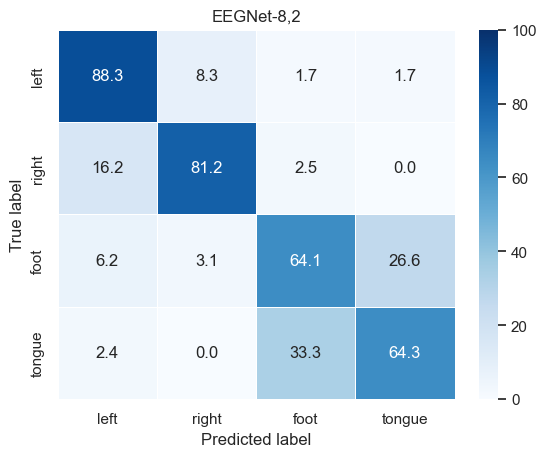

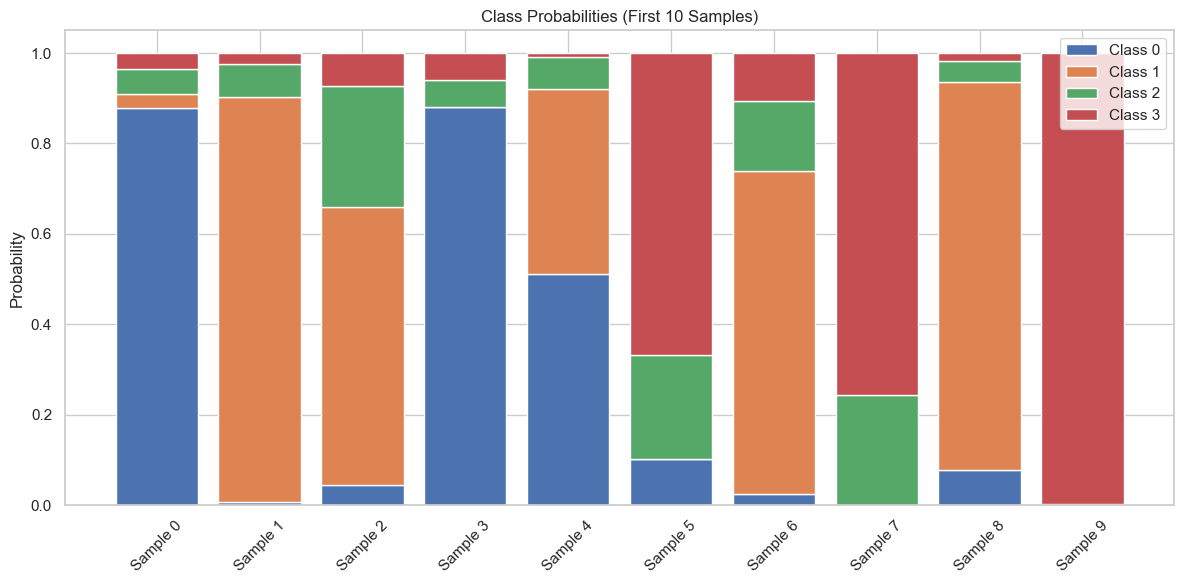

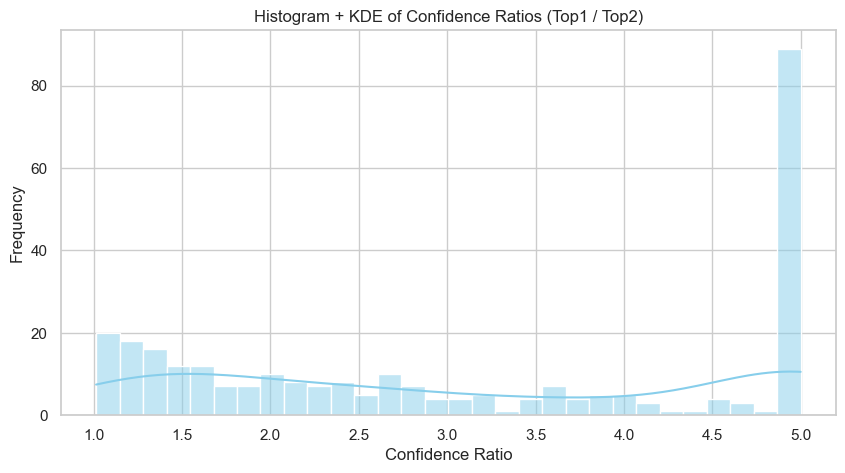

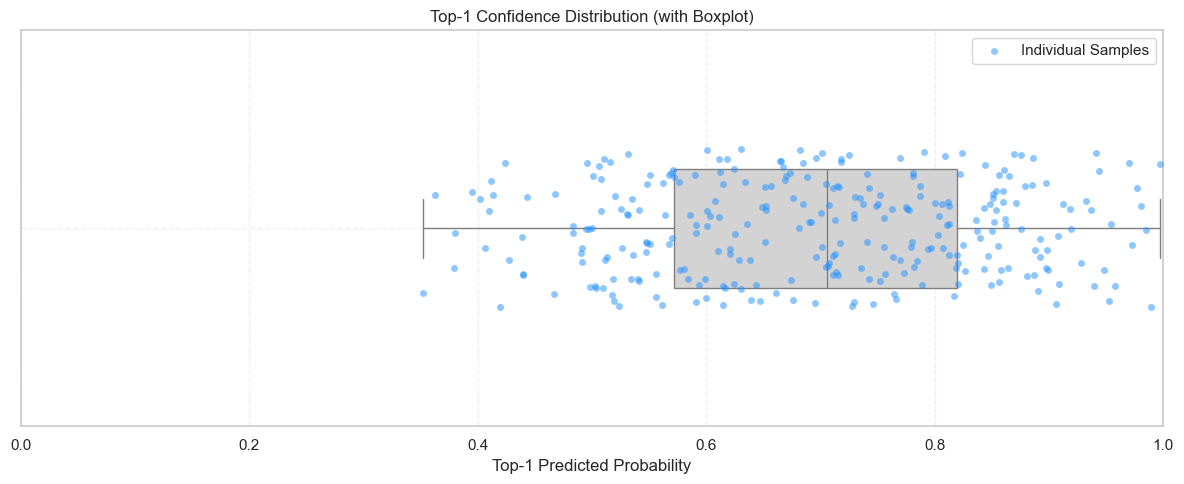

Average confidence of selected class:  0.69609374


In [20]:
#########################################################################################################

# load optimal weights
model.load_weights('/tmp/checkpoint.h5')

#predict
print(model.summary())
probs = model.predict(X_test)

#k=1.2 # If k is 1, just accept all highest probs (preds       = probs.argmax(axis = -1)  )
# k >= 1

#preds, Y_test, mask = accept_confident_probabilities(probs, k, Y_test)
#omitted = X_test[~mask]

preds = probs.argmax(axis = -1)

acc = np.mean(preds == Y_test.argmax(axis=-1))
print("Classification accuracy EEGNet: %f " % (acc))
#print(len(omitted), " samples deleted")

plt.figure(0)
plot_confusion_matrix(preds, Y_test.argmax(axis = -1), names, title = 'EEGNet-8,2')

# XDAWN RG 
# Only works in time series
# Also doesnt seem to work with BCI 2B
#util.xdawnrg(X_train, X_test, Y_train, Y_test, chans, samples, names)

# Show only the first 10 samples for clarity
samples_to_plot = 10
util.plot_predicted_probs(probs, samples_to_plot)

# Plot all confidences
util.plot_prediction_confidence(probs)

# plot all selected probs
util.plot_all_predicted_probabilities(probs)
print("Average confidence of selected class: ", np.mean(probs.max(axis=1)))
